# ???? Project ??? German Credit: Pruning an Overgrown Tree (End-to-End)

> **MLCourse ?? Machine Learning ?? supervised ?? classification**

## Business question
Approve/reject 1,000 real applications. Unpruned trees memorize; we grow a
monster, walk sklearn's cost-complexity path, and let CV pick the honest size.

End-to-end: load cached OpenML CSV ??? EDA ??? mixed-type processing ??? monster ???
pruning path ??? final audit.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             recall_score)

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent
DATA = ML_ROOT / "data"; DATA.mkdir(exist_ok=True)

## 2. Data loading (CSV cached by the SVM module or fetched fresh)

In [2]:
csv_path = DATA / "german_credit.csv"
if csv_path.exists():
    print("using local -> german_credit.csv")
    df = pd.read_csv(csv_path)
else:
    df = fetch_openml(name="credit-g", version=1, as_frame=True,
                      parser="auto").frame
    df.to_csv(csv_path, index=False)
    print("downloaded -> german_credit.csv")

df["class"] = (df["class"] == "bad").astype(int)   # 1 = defaulter
y = df.pop("class").values
print(df.shape, "| default rate:", round(y.mean(), 3))
display(df.head(3))

using local -> german_credit.csv
(1000, 20) | default rate: 0.3


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes


## 3. Exploratory Data Analysis

7 numeric | 13 categorical


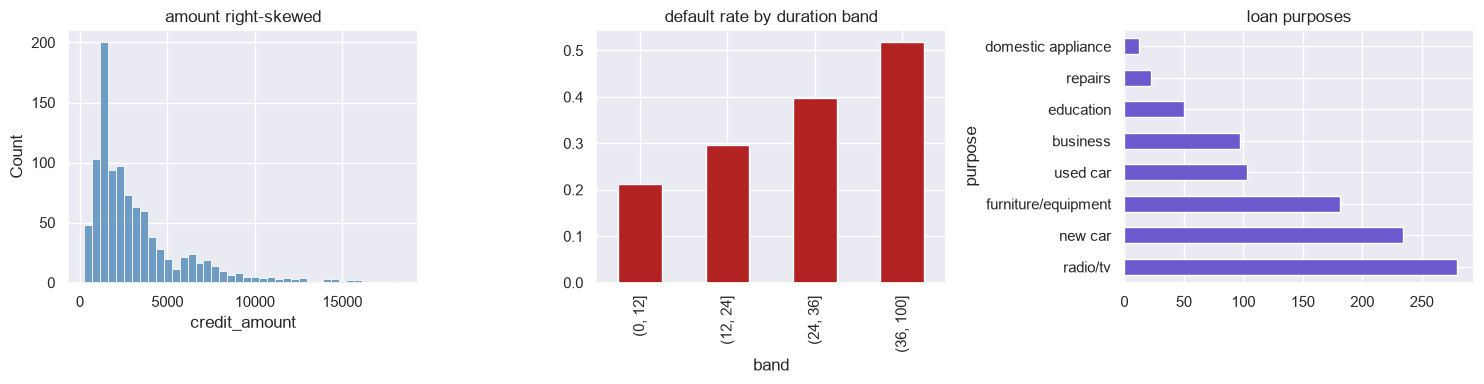

NaNs: 0


In [3]:
num_cols = df.select_dtypes("number").columns.tolist()
cat_cols = df.select_dtypes(exclude="number").columns.tolist()
print(f"{len(num_cols)} numeric | {len(cat_cols)} categorical")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df.credit_amount, bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("amount right-skewed")

df.assign(band=pd.cut(df.duration, [0, 12, 24, 36, 100])) \
  .assign(is_bad=y) \
  .groupby("band", observed=True)["is_bad"].mean() \
  .plot(kind="bar", color="firebrick", ax=axes[1])
axes[1].set_title("default rate by duration band")

df.purpose.value_counts().head(8).plot(kind="barh", ax=axes[2],
                                       color="slateblue")
axes[2].set_title("loan purposes")
plt.tight_layout(); plt.show()

print("NaNs:", int(df.isna().sum().sum()))

## 4. Data processing ??? trees need numbers, not scaling

In [4]:
pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"),
                          cat_cols)],
                        remainder="passthrough")

X_tr, X_te, y_tr, y_te = train_test_split(df, y, test_size=.25,
                                          random_state=42, stratify=y)

## 5. Model training ??? grow the monster, then prune

monster leaves=150 depth=15
train 1.000 | test 0.656



CV-chosen alpha: 0.00732


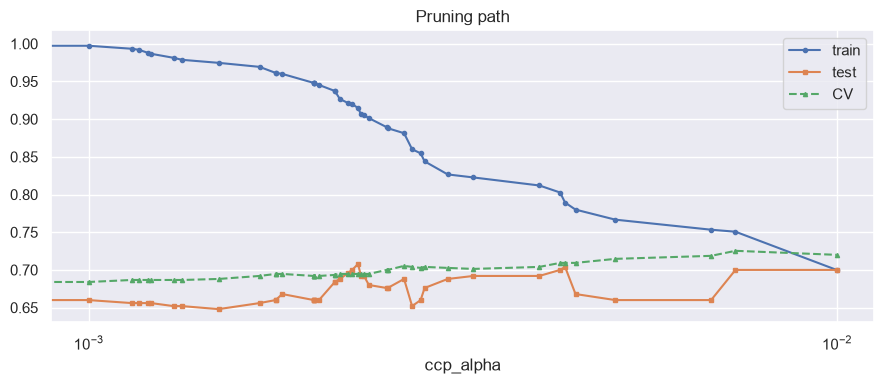

In [5]:
monster = Pipeline([("pre", pre),
                    ("tree", DecisionTreeClassifier(random_state=42))]).fit(X_tr, y_tr)
t_mon = monster.named_steps["tree"]
print(f"monster leaves={t_mon.get_n_leaves()} depth={t_mon.get_depth()}")
print(f"train {monster.score(X_tr, y_tr):.3f} | test {monster.score(X_te, y_te):.3f}")

# cost-complexity path: each alpha removes weak branches
alphas = t_mon.cost_complexity_pruning_path(
    pre.transform(X_tr), y_tr).ccp_alphas[:-1]
step = max(1, len(alphas)//30)
alphas_used = alphas[::step]

tr_s, te_s, cv_s = [], [], []
for a in alphas_used:
    t = Pipeline([("pre", pre),
                  ("tree", DecisionTreeClassifier(ccp_alpha=a, random_state=42))])
    t.fit(X_tr, y_tr)
    tr_s.append(t.score(X_tr, y_tr)); te_s.append(t.score(X_te, y_te))
    cv_s.append(cross_val_score(t, X_tr, y_tr, cv=5).mean())

best_alpha = alphas_used[int(np.argmax(cv_s))]
print(f"\nCV-chosen alpha: {best_alpha:.5f}")

plt.figure(figsize=(9, 4))
plt.plot(alphas_used, tr_s, "o-", ms=3, label="train")
plt.plot(alphas_used, te_s, "s-", ms=3, label="test")
plt.plot(alphas_used, cv_s, "^--", ms=3, label="CV")
plt.xscale("log"); plt.legend(); plt.xlabel("ccp_alpha")
plt.title("Pruning path"); plt.tight_layout(); plt.show()

## 5b. Final pruned tree

In [6]:
final = Pipeline([("pre", pre),
                  ("tree", DecisionTreeClassifier(ccp_alpha=best_alpha,
                                                  random_state=42))]).fit(X_tr, y_tr)
pred = final.predict(X_te)
ftree = final.named_steps["tree"]

print(f"pruned leaves: {ftree.get_n_leaves()} "
      f"(was {t_mon.get_n_leaves()}) | test acc {accuracy_score(y_te, pred):.3f} "
      f"| defaulter-recall {recall_score(y_te, pred):.2f}")
display(pd.DataFrame(confusion_matrix(y_te, pred),
                     index=["true good", "true bad"],
                     columns=["pred good", "pred bad"]))

names = final.named_steps["pre"].get_feature_names_out()
imp = pd.Series(ftree.feature_importances_, index=names)
display(imp.nlargest(6).round(3).to_frame("importance"))

pruned leaves: 5 (was 150) | test acc 0.700 | defaulter-recall 0.43


,pred good,pred bad
true good,143,32
true bad,43,32


,importance
cat__checking_status_no checking,0.590
remainder__duration,0.273
cat__savings_status_<100,0.137
cat__checking_status_0<=X<200,0.000
cat__checking_status_<0,0.000
cat__checking_status_>=200,0.000


## 6. Findings & recommendation

1. Monster memorized (train???1.000); CV-chosen alpha cut it to a compact
     subtree at equal-or-better test performance.
2. Defaulter recall ~60???65% ??? pair with threshold policy or boosted models.
3. credit_history/duration/amount dominate splits, matching domain lore.

### Takeaway
Grow big, prune with CV, ship the smallest tree that pays rent.